# DNV-RP-F114 pipe-soil interaction screening

This example uses NeqSim's edition-aware `DnvRpF114PipeSoilInteractionScreeningKernel` for the current `DNV-RP-F114 2021-05` basis. It compares externally established vertical, axial, and lateral design-action magnitudes with caller-controlled pipe-soil resistance magnitudes for named route locations and design situations.

> **Boundary:** this is a regression-backed `SCREENING` calculation, not DNV conformity. Site investigation, soil interpretation, penetration/burial and load-displacement models, installation history, cyclic/drainage/rate/time effects, characteristic values, uncertainty, structural actions, adjacent standards, and approval remain external. NeqSim soil thermal inputs are not geotechnical resistance evidence.

In [1]:
from pathlib import Path
import os
import sys
import jpype

ROOT = Path.cwd().resolve()
while not (ROOT / 'pom.xml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'pom.xml').exists(), 'Run this notebook from the NeqSim repository tree'

if not jpype.isJVMStarted():
    local_classpath = os.environ.get('NEQSIM_NOTEBOOK_CLASSPATH')
    if local_classpath:
        jpype.startJVM(classpath=local_classpath.split(os.pathsep), convertStrings=True)
    else:
        sys.path.insert(0, str(ROOT / 'devtools'))
        from neqsim_dev_setup import neqsim_init
        neqsim_init(project_root=ROOT, recompile=not (ROOT / 'target/classes').exists(), verbose=False)

from jpype import JClass
import pandas as pd
import matplotlib.pyplot as plt
print('Workspace kernel loaded:', ROOT)

Workspace kernel loaded: /workspace/scratch/de313162ffce/repo_f114


## 1. Verified demonstration basis

The values below are project-controlled demonstration inputs, not F114 soil parameters, factors, or acceptance criteria. In a project, every demand and resistance would come from controlled structural and geotechnical models on a consistent basis. The Boolean flags attest that the underlying evidence was reviewed; the flags are not the evidence.

In [2]:
StandardType = JClass('neqsim.process.mechanicaldesign.designstandards.StandardType')
StandardEdition = JClass('neqsim.process.mechanicaldesign.designstandards.StandardEdition')
Kernel = JClass('neqsim.process.engineering.calculation.DnvRpF114PipeSoilInteractionScreeningKernel')
Input = JClass('neqsim.process.engineering.calculation.DnvRpF114PipeSoilInteractionScreeningKernel$Input')
InteractionCase = JClass('neqsim.process.engineering.calculation.DnvRpF114PipeSoilInteractionScreeningKernel$InteractionCase')

edition = StandardEdition.defaultEdition(StandardType.DNV_RP_F114)
kernel = Kernel()
nominal_cases = [
    ('route section 1', 0.0, 'installation', 200.0, 500.0, 80.0, 160.0, 120.0, 240.0),
    ('route section 2', 12_000.0, 'operation', 300.0, 600.0, 100.0, 250.0, 220.0, 275.0),
]

def run_screen(cases=nominal_cases, site_evidence=True):
    builder = (Input.builder(edition, 'Pipeline')
        .pipelineOuterDiameterM(0.3239)
        .submergedWeightNPerM(1200.0)
        .applicabilityVerified(True)
        .siteInvestigationVerified(site_evidence)
        .soilModelVerified(True)
        .pipelineConfigurationVerified(True)
        .installationHistoryVerified(True)
        .cyclicDrainageRateEffectsVerified(True)
        .loadDisplacementAndResistanceVerified(True)
        .uncertaintyAndVariabilityVerified(True)
        .designActionsAndAcceptanceCriteriaVerified(True)
        .interfacesAndLifecycleReviewed(True))
    for case in cases:
        builder.addInteractionCase(InteractionCase(*case))
    return kernel.calculate(builder.build(), None)

result = run_screen()
assessment = result.getValue()
summary = pd.Series({
    'status': str(result.getStatus()),
    'edition': str(assessment.getStandardEdition()),
    'minimum vertical margin [N/m]': float(assessment.getMinimumVerticalMarginNPerM()),
    'minimum axial margin [N/m]': float(assessment.getMinimumAxialMarginNPerM()),
    'minimum lateral margin [N/m]': float(assessment.getMinimumLateralMarginNPerM()),
    'maximum lateral utilization [-]': float(assessment.getMaximumLateralUtilization()),
    'all caller-controlled constraints satisfied': bool(assessment.allConstraintsSatisfied()),
    'engineering approval required': bool(assessment.toMap().get('engineeringApprovalRequired')),
})
assert str(result.getStatus()) == 'CALCULATED_REVIEW_REQUIRED'
assert abs(float(assessment.getMinimumLateralMarginNPerM()) - 55.0) < 1e-12
assert abs(float(assessment.getMaximumLateralUtilization()) - 0.8) < 1e-12
assert bool(assessment.allConstraintsSatisfied())
summary.to_frame('screening result')

,screening result
status,CALCULATED_REVIEW_REQUIRED
edition,DNV-RP-F114 2021-05
minimum vertical margin [N/m],300.0
minimum axial margin [N/m],80.0
minimum lateral margin [N/m],55.0
maximum lateral utilization [-],0.8
all caller-controlled constraints satisfied,True
engineering approval required,True


## 2. Direction-specific utilization

The chart visualizes only the implemented demand-to-resistance ratios. The underlying resistance models and the project interpretation of utilization remain external.

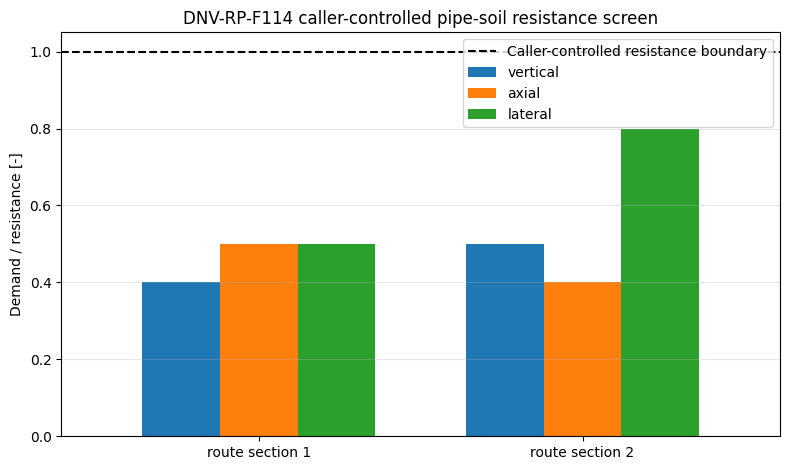

,distance [km],vertical,axial,lateral
case,,,,
route section 1,0.0,0.4,0.5,0.5
route section 2,12.0,0.5,0.4,0.8


In [3]:
rows = [{
    'case': str(item.getLabel()),
    'distance [km]': float(item.getDistanceM()) / 1000.0,
    'vertical': float(item.getVerticalUtilization()),
    'axial': float(item.getAxialUtilization()),
    'lateral': float(item.getLateralUtilization()),
} for item in assessment.getInteractionCases()]
table = pd.DataFrame(rows).set_index('case')

ax = table[['vertical', 'axial', 'lateral']].plot.bar(figsize=(8, 4.8), width=0.72)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Caller-controlled resistance boundary')
ax.set_ylabel('Demand / resistance [-]')
ax.set_xlabel('')
ax.set_title('DNV-RP-F114 caller-controlled pipe-soil resistance screen')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
assert (table[['vertical', 'axial', 'lateral']] <= 1.0).all().all()
plt.show()
table

**Figure discussion.** Route section 2 has the governing lateral utilization of 0.8 for this demonstration, while route section 1 and the other directions remain lower. This does not establish acceptance: verify that every demand, resistance, displacement level, design situation, factor, and uncertainty treatment uses the approved project basis.

<p><strong>Figure alt text:</strong> Grouped bar chart of caller-controlled vertical, axial, and lateral pipe-soil demand-to-resistance utilization for two generic route sections, with a dashed boundary at utilization one.</p>

## 3. An exceeded resistance remains visible

A verified case with lateral demand above the supplied resistance is still calculated. This separates evidence readiness from the engineering finding.

In [4]:
exceeded_cases = [
    ('route section 1', 0.0, 'operation', 200.0, 500.0, 80.0, 160.0, 300.0, 250.0),
]
exceeded = run_screen(cases=exceeded_cases)
exceeded_assessment = exceeded.getValue()
finding = pd.Series({
    'status': str(exceeded.getStatus()),
    'minimum lateral margin [N/m]': float(exceeded_assessment.getMinimumLateralMarginNPerM()),
    'maximum lateral utilization [-]': float(exceeded_assessment.getMaximumLateralUtilization()),
    'all caller-controlled constraints satisfied': bool(exceeded_assessment.allConstraintsSatisfied()),
    'interpretation': 'Calculated screening finding; project review and action required',
})
assert str(exceeded.getStatus()) == 'CALCULATED_REVIEW_REQUIRED'
assert abs(float(exceeded_assessment.getMinimumLateralMarginNPerM()) + 50.0) < 1e-12
assert not bool(exceeded_assessment.allConstraintsSatisfied())
finding.to_frame('exceeded case')

,exceeded case
status,CALCULATED_REVIEW_REQUIRED
minimum lateral margin [N/m],-50.0
maximum lateral utilization [-],1.2
all caller-controlled constraints satisfied,False
interpretation,Calculated screening finding; project review a...


## 4. Fail closed when site evidence is missing

Numeric resistance values are not self-validating. The same values are blocked when the site-investigation evidence flag is false. Retain survey scope, sampling and tests, data quality, interpretation, spatial coverage, uncertainty, and accountable review beside the screen.

In [5]:
blocked = run_screen(site_evidence=False)
findings = pd.DataFrame([{
    'code': str(item.toMap().get('code')),
    'severity': 'BLOCKER',
    'message': str(item.toMap().get('message')),
} for item in blocked.getReadiness().getBlockers()])
assert str(blocked.getStatus()) == 'BLOCKED'
assert blocked.getValue() is None
assert 'DNV_RP_F114_SITE_INVESTIGATION_NOT_VERIFIED' in set(findings['code'])
findings

,code,severity,message
0,DNV_RP_F114_SITE_INVESTIGATION_NOT_VERIFIED,BLOCKER,Site-investigation coverage and data quality h...
